In [ ]:
import pandas as pd

df = pd.read_csv('/content/loan_data_new.csv')

df.head()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


In [ ]:
print(df.shape)

df.info()

df.isnull().sum()

(45000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  45000 non-null  int64  
 1   Gender               45000 non-null  object 
 2   Education            45000 non-null  object 
 3   Person Income        45000 non-null  int64  
 4   Employee Experience  45000 non-null  int64  
 5   Home Onwership       45000 non-null  object 
 6   Loan Amount          45000 non-null  int64  
 7   Loan Intent          45000 non-null  object 
 8   Loan interest Rate   45000 non-null  float64
 9   Loan percentage      45000 non-null  float64
 10  Credit History       45000 non-null  int64  
 11  Credit Score         45000 non-null  int64  
 12  Previous Loan        45000 non-null  object 
 13  Loan Status          45000 non-null  int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 4.8+ MB


,0
Age,0
Gender,0
Education,0
Person Income,0
Employee Experience,0
Home Onwership,0
Loan Amount,0
Loan Intent,0
Loan interest Rate,0
Loan percentage,0


In [ ]:
df['Loan Status'].value_counts()

,count
Loan Status,
0,35000
1,10000


In [ ]:
plt.figure(figsize=(5,4))

sns.countplot(x='Loan Status', data=df)

plt.title("Loan Approval Distribution")

plt.show()

NameError: name 'plt' is not defined

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

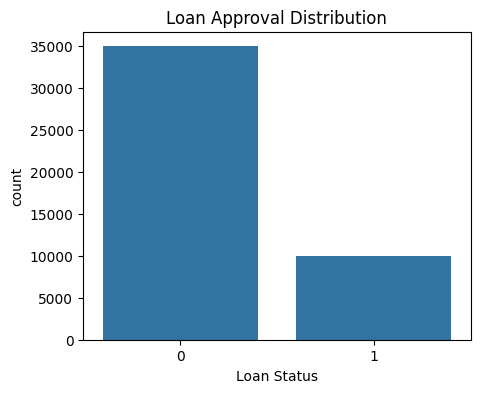

In [ ]:
plt.figure(figsize=(5,4))

sns.countplot(x='Loan Status', data=df)

plt.title("Loan Approval Distribution")

plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'Gender',
    'Education',
    'Home Ownership',
    'Loan Intent',
    'Previous Loan'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

KeyError: 'Home Ownership'

In [ ]:
for col in df.columns:
    print(col)

Age
Gender
Education
Person Income
Employee Experience
Home Onwership
Loan Amount
Loan Intent
Loan interest Rate
Loan percentage
Credit History
Credit Score
Previous Loan
Loan Status


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,22,0,4,71948,0,3,35000,4,16.02,0.49,3,561,0,1
1,21,0,3,12282,0,2,1000,1,11.14,0.08,2,504,1,0
2,25,0,3,12438,3,0,5500,3,12.87,0.44,3,635,0,1
3,23,0,1,79753,0,3,35000,3,15.23,0.44,2,675,0,1
4,24,1,4,66135,1,3,35000,3,14.27,0.53,4,586,0,1


In [ ]:
X = df.drop('Loan Status', axis=1)
y = df['Loan Status']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(36000, 13)
(9000, 13)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93      6990
           1       0.77      0.73      0.75      2010

    accuracy                           0.89      9000
   macro avg       0.84      0.83      0.84      9000
weighted avg       0.89      0.89      0.89      9000



In [17]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.93      0.94      0.93      6990
           1       0.77      0.77      0.77      2010

    accuracy                           0.90      9000
   macro avg       0.85      0.85      0.85      9000
weighted avg       0.90      0.90      0.90      9000



In [18]:
from sklearn.metrics import roc_auc_score

roc_lr = roc_auc_score(y_test, y_pred_lr)

print("Logistic Regression ROC AUC:", roc_lr)

Logistic Regression ROC AUC: 0.8333771058868746


In [19]:
roc_dt = roc_auc_score(y_test, y_pred_dt)

print("Decision Tree ROC AUC:", roc_dt)

Decision Tree ROC AUC: 0.8519964554907864


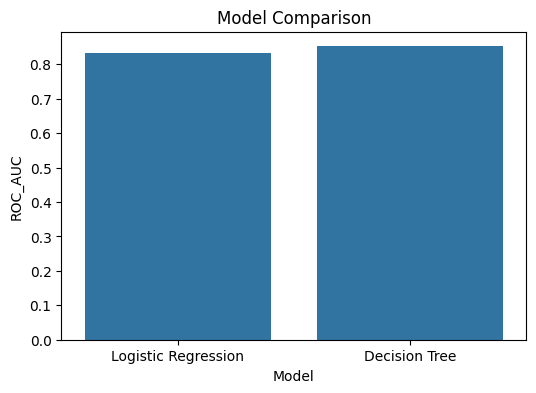

In [20]:
comparison = pd.DataFrame({'Model':['Logistic Regression','Decision Tree'],'ROC_AUC':[roc_lr, roc_dt]})plt.figure(figsize=(6,4))sns.barplot(x='Model',y='ROC_AUC',data=comparison)plt.title("Model Comparison")plt.show()